<a href="https://colab.research.google.com/github/pyo-lee/kumc-radiology-ai-workflow-course/blob/main/python-csv-structure-and-basic-processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSV 파일이란?

CSV는 **Comma-Separated Values**의 약자로, 데이터를 쉼표(`,`)로 구분하여 저장하는 텍스트 파일 형식이다.  
쉽게 말해, 엑셀 표처럼 행과 열로 구성된 데이터를 간단한 텍스트 형태로 저장한 파일이다.

CSV 파일의 확장자는 보통 `.csv`이다.

---

## 1. CSV 파일의 기본 구조

CSV 파일은 다음과 같이 구성된다.

- 한 줄은 하나의 데이터 행을 의미한다.
- 쉼표(`,`)는 열을 구분하는 역할을 한다.
- 첫 번째 줄은 보통 컬럼명, 즉 변수명을 나타낸다.

예를 들어 다음과 같은 CSV 파일이 있다고 가정하자.

```text
patient_id,age,gender,diagnosis,readmitted
1,65,Female,Diabetes,NO
2,72,Male,Diabetes,<30
3,58,Female,Hypertension,>30

In [1]:
import pandas as pd
df_sample = pd.read_csv("/content/sample_data/california_housing_train.csv")
df_sample

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0


# Diabetes 130-US Hospitals for Years 1999-2008 데이터셋 소개

## 1. 데이터셋 개요

**Diabetes 130-US Hospitals for Years 1999-2008** 데이터셋은 1999년부터 2008년까지 미국 130개 병원 및 통합 의료 네트워크에서 수집된 당뇨병 입원 환자 기록 데이터이다. 각 행은 한 명의 환자 자체가 아니라, 당뇨병 진단을 받은 환자의 **한 번의 입원 encounter**를 의미한다.

이 데이터셋의 주요 목적은 환자가 퇴원 후 **30일 이내에 재입원할지 여부**를 예측하는 것이다. 따라서 의료 EMR 데이터를 이용한 예측 모델링, 데이터 전처리, 결측치 처리, 범주형 변수 인코딩 실습에 적합하다.


In [2]:
import pandas as pd
import zipfile
import os

url = "https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip"

zip_path = "/content/diabetes_data.zip"
extract_dir = "/content/diabetes_data"

# SSL 인증서 검증을 생략하고 다운로드
!wget --no-check-certificate -O {zip_path} "{url}"

# 정상 zip 파일인지 확인
if not zipfile.is_zipfile(zip_path):
    raise ValueError("다운로드된 파일이 zip 파일이 아닙니다. 다운로드가 정상적으로 되었는지 확인하세요.")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print(os.listdir(extract_dir))

--2026-05-25 13:38:24--  https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘/content/diabetes_data.zip’

/content/diabetes_d     [   <=>              ]   3.02M  6.35MB/s    in 0.5s    

2026-05-25 13:38:25 (6.35 MB/s) - ‘/content/diabetes_data.zip’ saved [3170254]

['IDS_mapping.csv', 'diabetic_data.csv']


In [3]:
import pandas as pd
df_sample = pd.read_csv("/content/diabetes_data/diabetic_data.csv")
df_sample

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO



## 2. 데이터셋 구성

| 항목 | 내용 |
|---|---|
| 데이터셋명 | Diabetes 130-US Hospitals for Years 1999-2008 |
| 데이터 출처 | UCI Machine Learning Repository |
| 수집 기간 | 1999년부터 2008년 |
| 수집 기관 | 미국 130개 병원 및 통합 의료 네트워크 |
| 데이터 단위 | 입원 encounter |
| 전체 샘플 수 | 101,766개 |
| 데이터 유형 | 다변량 표 형식 데이터 |
| 변수 유형 | 범주형 변수, 정수형 변수 |
| 주요 분석 목적 | 퇴원 후 조기 재입원 여부 예측 |
| 대표 task | Classification, Clustering |
| 결측값 포함 여부 | 있음 |

## 3. 데이터 포함 기준

이 데이터셋은 다음 조건을 만족하는 입원 기록을 대상으로 구성되었다.

1. 병원 입원 encounter일 것
2. 당뇨병 진단이 기록된 encounter일 것
3. 입원 기간이 최소 1일 이상, 최대 14일 이하일 것
4. 입원 중 laboratory test가 시행되었을 것
5. 입원 중 medication이 투여되었을 것

# Diabetes 130-US Hospitals Dataset 컬럼 설명

이 데이터셋은 당뇨병으로 입원한 환자의 병원 기록을 기반으로 구성된 EMR-like tabular dataset이다.  
각 행은 한 명의 환자에 대한 단순 정보가 아니라, 한 번의 병원 입원 encounter를 의미한다.


In [4]:
df = pd.read_csv("/content/diabetes_data/diabetic_data.csv")
df


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [5]:
df_m = pd.read_csv("/content/diabetes_data/IDS_mapping.csv")
df_m

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
...,...,...
62,22,Transfer from hospital inpt/same fac reslt in...
63,23,Born inside this hospital
64,24,Born outside this hospital
65,25,Transfer from Ambulatory Surgery Center


In [6]:
df.head(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [7]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

## 컬럼별 변수 (X) 및 의미

| 컬럼명 | 변수 유형 | 의미 | 강의 설명 포인트 |
|---|---|---|---|
| `encounter_id` | ID | 입원 encounter의 고유 식별자 | 모델 학습 feature에서는 보통 제외 |
| `patient_nbr` | ID | 환자의 고유 식별자 | 한 환자가 여러 번 입원했을 수 있음 |
| `race` | 범주형 | 환자의 인종 정보 | Caucasian, AfricanAmerican, Asian, Hispanic, Other, `?` |
| `gender` | 범주형 | 환자의 성별 | Female, Male, Unknown/Invalid |
| `age` | 범주형 | 환자의 연령대 | `[0-10)`, `[10-20)`, ..., `[90-100)` |
| `weight` | 범주형 | 환자의 체중 구간 | 실제 CSV에서는 구간형 문자열과 `?`로 저장됨 |
| `admission_type_id` | 범주형 코드 | 입원 유형 코드 | Emergency, Urgent, Elective 등으로 매핑 필요 |
| `discharge_disposition_id` | 범주형 코드 | 퇴원 후 상태 또는 이동 장소 코드 | 자택 퇴원, 전원, 사망, 호스피스 등으로 매핑 필요 |
| `admission_source_id` | 범주형 코드 | 입원 경로 코드 | 의뢰, 응급실, 타 병원 전원 등으로 매핑 필요 |
| `time_in_hospital` | 수치형 | 입원 기간 | 입원일부터 퇴원일까지의 일수 |
| `payer_code` | 범주형 | 보험 또는 지불자 코드 | Medicare, Medicaid, self-pay 등 |
| `medical_specialty` | 범주형 | 입원 담당 의사의 진료과 | Internal Medicine, Emergency/Trauma, Cardiology 등 |
| `num_lab_procedures` | 수치형 | 입원 중 시행된 검사실 검사 수 | lab test 개수 |
| `num_procedures` | 수치형 | 입원 중 시행된 처치 또는 시술 수 | lab test를 제외한 procedure 개수 |
| `num_medications` | 수치형 | 입원 중 투여된 약물 종류 수 | 서로 다른 generic medication의 개수 |
| `number_outpatient` | 수치형 | 이전 1년간 외래 방문 횟수 | 과거 의료 이용량 |
| `number_emergency` | 수치형 | 이전 1년간 응급실 방문 횟수 | 과거 응급 의료 이용량 |
| `number_inpatient` | 수치형 | 이전 1년간 입원 횟수 | 과거 입원력 |
| `diag_1` | 범주형 코드 | 주진단 코드 | ICD-9 기반 primary diagnosis |
| `diag_2` | 범주형 코드 | 제2진단 코드 | ICD-9 기반 secondary diagnosis |
| `diag_3` | 범주형 코드 | 제3진단 코드 | ICD-9 기반 additional diagnosis |
| `number_diagnoses` | 수치형 | 기록된 진단 개수 | 동반질환 또는 질병 복잡도와 관련 |
| `max_glu_serum` | 범주형 | 혈청 glucose 검사 결과 | `>200`, `>300`, `Norm`, `None` |
| `A1Cresult` | 범주형 | HbA1c 검사 결과 | `>7`, `>8`, `Norm`, `None` |
| `metformin` | 범주형 | Metformin 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `repaglinide` | 범주형 | Repaglinide 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `nateglinide` | 범주형 | Nateglinide 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `chlorpropamide` | 범주형 | Chlorpropamide 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `glimepiride` | 범주형 | Glimepiride 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `acetohexamide` | 범주형 | Acetohexamide 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `glipizide` | 범주형 | Glipizide 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `glyburide` | 범주형 | Glyburide 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `tolbutamide` | 범주형 | Tolbutamide 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `pioglitazone` | 범주형 | Pioglitazone 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `rosiglitazone` | 범주형 | Rosiglitazone 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `acarbose` | 범주형 | Acarbose 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `miglitol` | 범주형 | Miglitol 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `troglitazone` | 범주형 | Troglitazone 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `tolazamide` | 범주형 | Tolazamide 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `examide` | 범주형 | Examide 처방 및 용량 변화 여부 | 대부분 No로 나타남 |
| `citoglipton` | 범주형 | Citoglipton 처방 및 용량 변화 여부 | 대부분 No로 나타남 |
| `insulin` | 범주형 | Insulin 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `glyburide-metformin` | 범주형 | Glyburide-metformin 복합제 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `glipizide-metformin` | 범주형 | Glipizide-metformin 복합제 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `glimepiride-pioglitazone` | 범주형 | Glimepiride-pioglitazone 복합제 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `metformin-rosiglitazone` | 범주형 | Metformin-rosiglitazone 복합제 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `metformin-pioglitazone` | 범주형 | Metformin-pioglitazone 복합제 처방 및 용량 변화 여부 | No, Steady, Up, Down |
| `change` | 범주형 | 당뇨 약물 변경 여부 | `Ch`: 변경 있음, `No`: 변경 없음 |
| `diabetesMed` | 범주형 | 당뇨 약물 처방 여부 | Yes 또는 No |
| `readmitted` | Target | 퇴원 후 재입원 여부 | `<30`, `>30`, `NO` |

## Target 변수 (Y)

이 데이터셋에서 가장 대표적인 target은 `readmitted`이다.

| 값 | 의미 |
|---|---|
| `<30` | 퇴원 후 30일 이내 재입원 |
| `>30` | 퇴원 후 30일 이후 재입원 |
| `NO` | 재입원 없음 |

In [8]:
df[["readmitted"]]

,readmitted
0,NO
1,>30
2,NO
3,NO
4,NO
...,...
101761,>30
101762,NO
101763,NO
101764,NO


In [9]:
df[["readmitted"]].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


## 3. Feature 그룹별 정리

| 그룹 | 포함 컬럼 |
|---|---|
| ID 변수 | `encounter_id`, `patient_nbr` |
| 인구학적 정보 | `race`, `gender`, `age`, `weight` |
| 입원 및 퇴원 정보 | `admission_type_id`, `discharge_disposition_id`, `admission_source_id`, `time_in_hospital` |
| 보험 및 진료과 정보 | `payer_code`, `medical_specialty` |
| 검사 및 처치 정보 | `num_lab_procedures`, `num_procedures`, `num_medications` |
| 과거 의료 이용 정보 | `number_outpatient`, `number_emergency`, `number_inpatient` |
| 진단 정보 | `diag_1`, `diag_2`, `diag_3`, `number_diagnoses` |
| 검사 결과 | `max_glu_serum`, `A1Cresult` |
| 약물 변경 및 당뇨약 사용 여부 | `change`, `diabetesMed` |
| 예측 대상 | `readmitted` |

### 개별 당뇨 약물 정보

다음 컬럼들은 개별 당뇨 약물의 처방 여부 및 용량 변화 여부를 나타낸다.

`No`: 처방 없음  
`Steady`: 용량 변화 없음  
`Up`: 용량 증가  
`Down`: 용량 감소  

- `metformin`
- `repaglinide`
- `nateglinide`
- `chlorpropamide`
- `glimepiride`
- `acetohexamide`
- `glipizide`
- `glyburide`
- `tolbutamide`
- `pioglitazone`
- `rosiglitazone`
- `acarbose`
- `miglitol`
- `troglitazone`
- `tolazamide`
- `examide`
- `citoglipton`
- `insulin`
- `glyburide-metformin`
- `glipizide-metformin`
- `glimepiride-pioglitazone`
- `metformin-rosiglitazone`
- `metformin-pioglitazone`

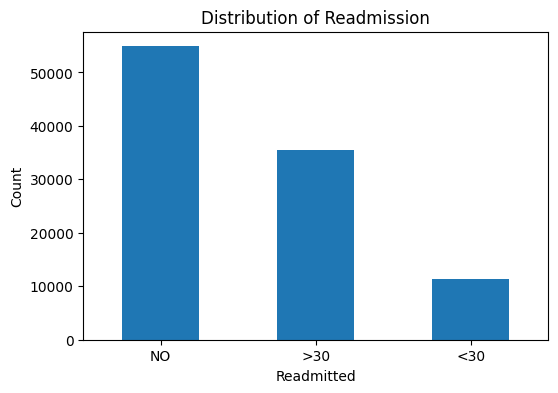

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

df["readmitted"].value_counts().plot(kind="bar")

plt.title("Distribution of Readmission")
plt.xlabel("Readmitted")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

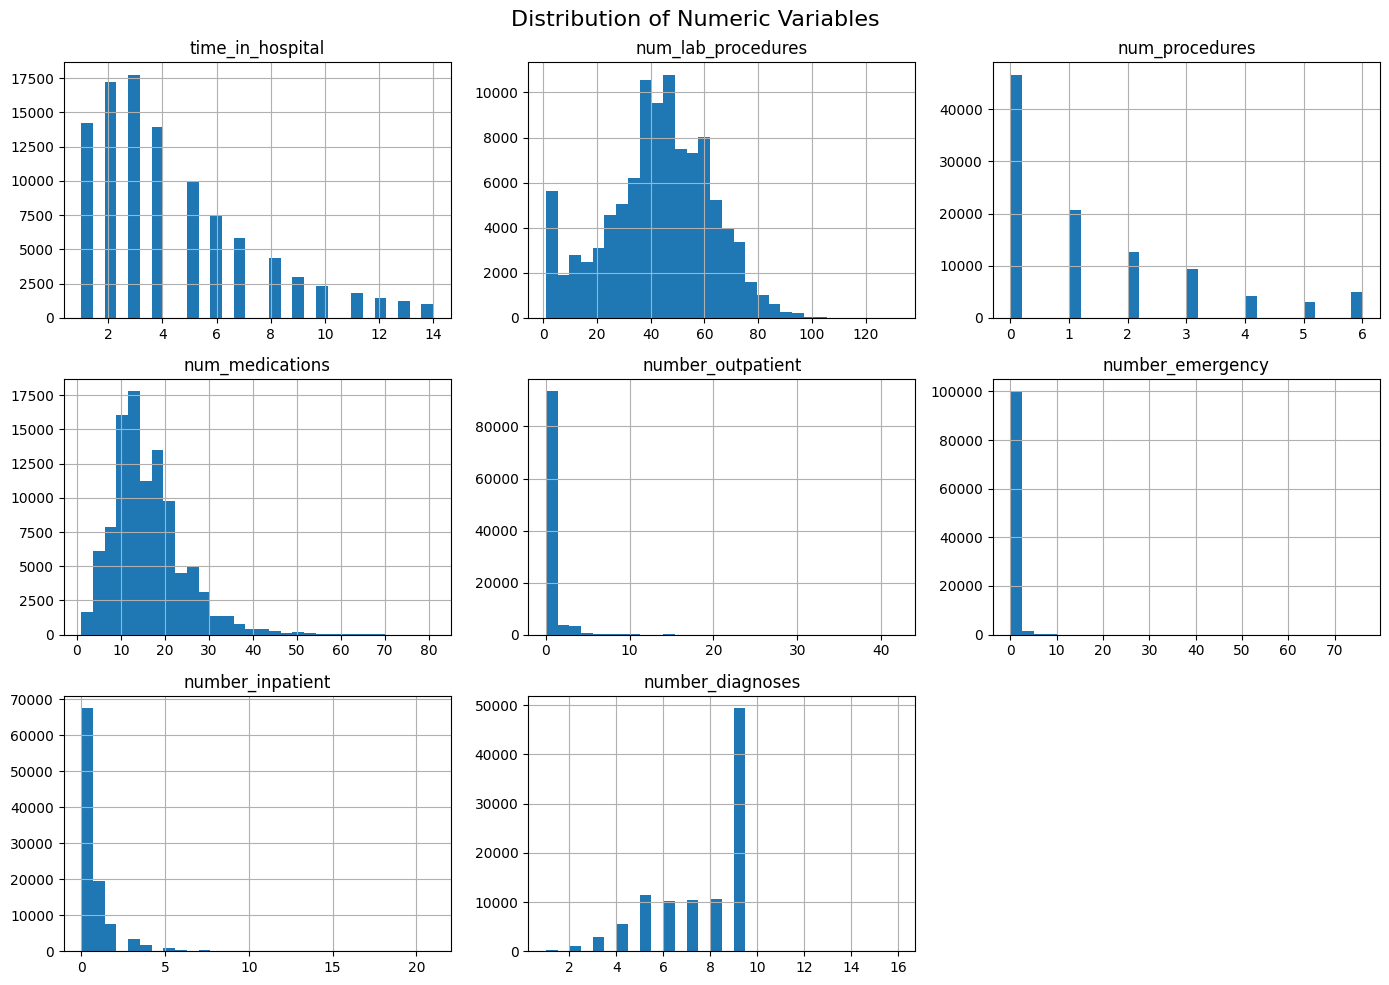

In [11]:
numeric_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

df[numeric_cols].hist(figsize=(14, 10), bins=30)

plt.suptitle("Distribution of Numeric Variables", fontsize=16)
plt.tight_layout()
plt.show()

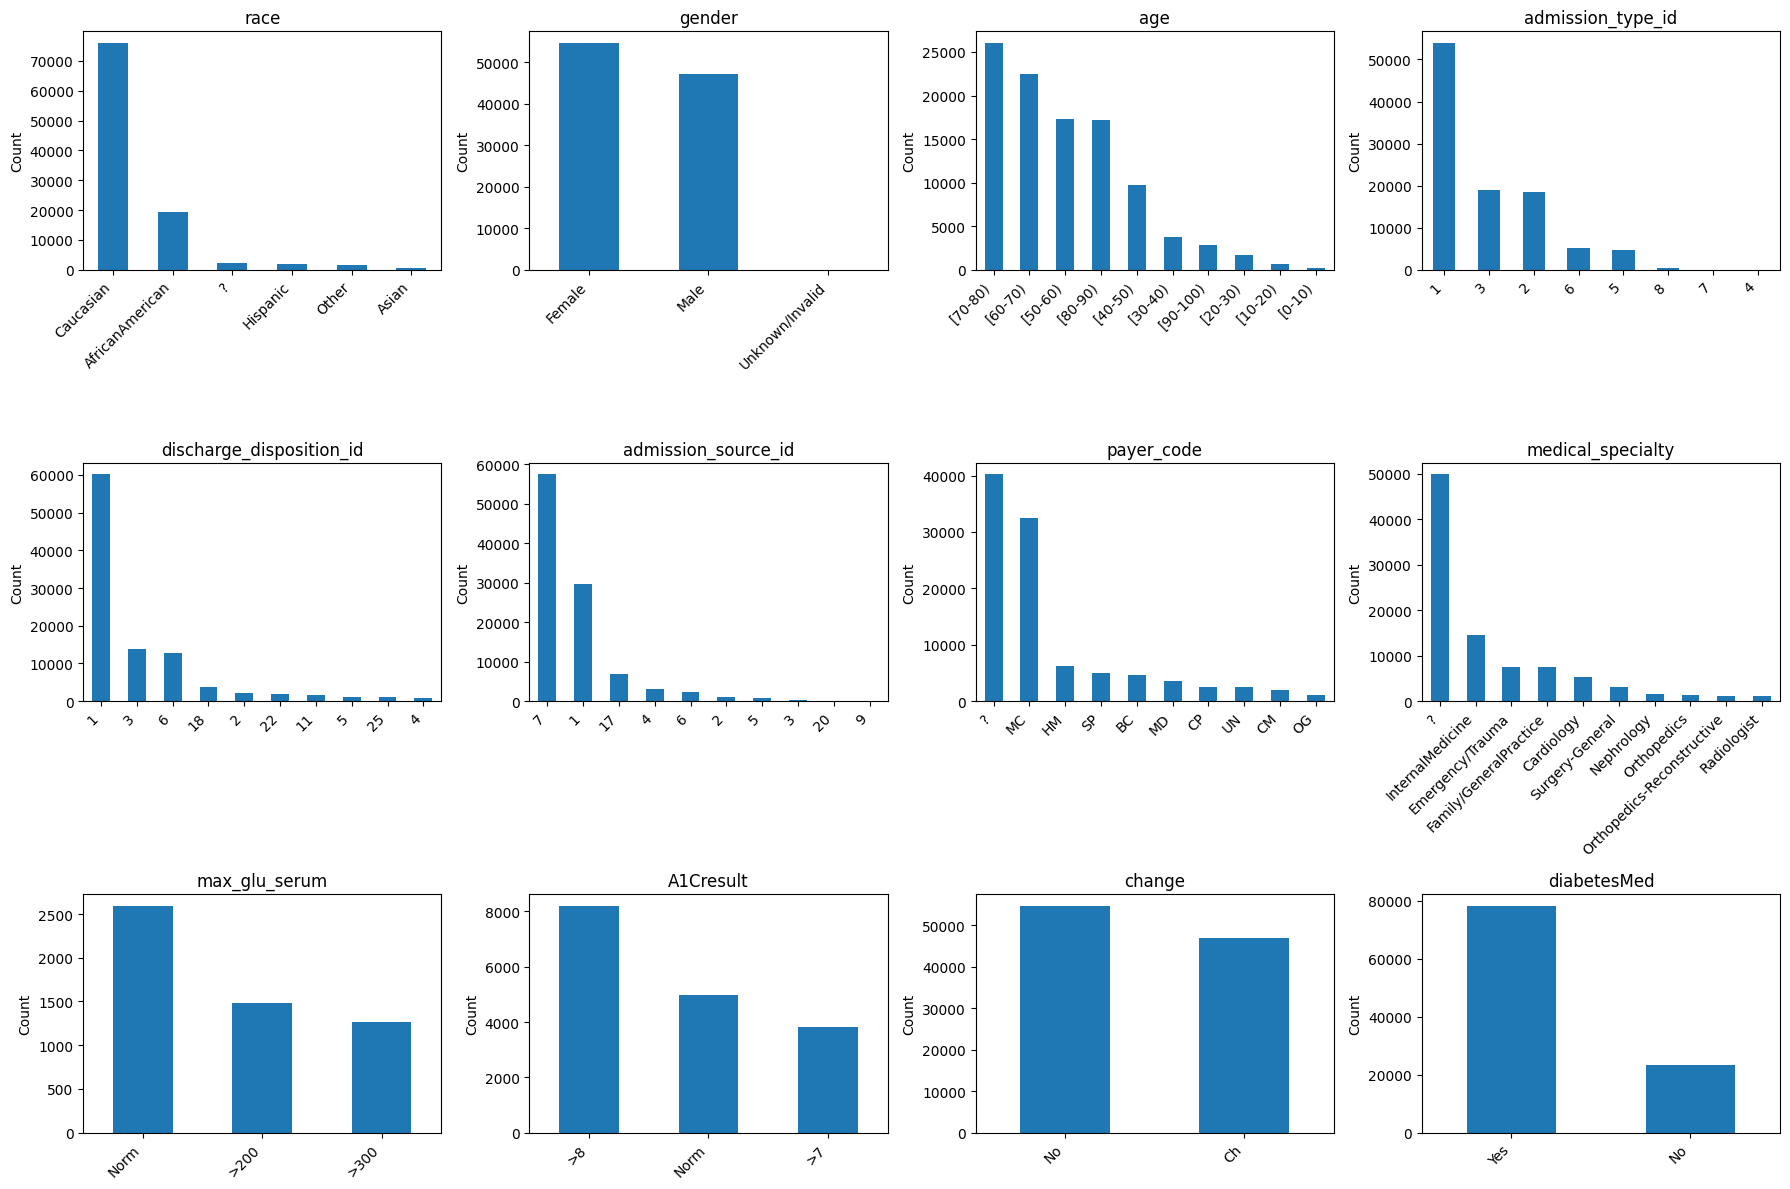

In [12]:
categorical_cols = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "payer_code",
    "medical_specialty",
    "max_glu_serum",
    "A1Cresult",
    "change",
    "diabetesMed"
]

n_cols = 4
n_rows = int(np.ceil(len(categorical_cols) / n_cols))

plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    df[col].value_counts().head(10).plot(kind="bar")

    plt.title(col)
    plt.xlabel("")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

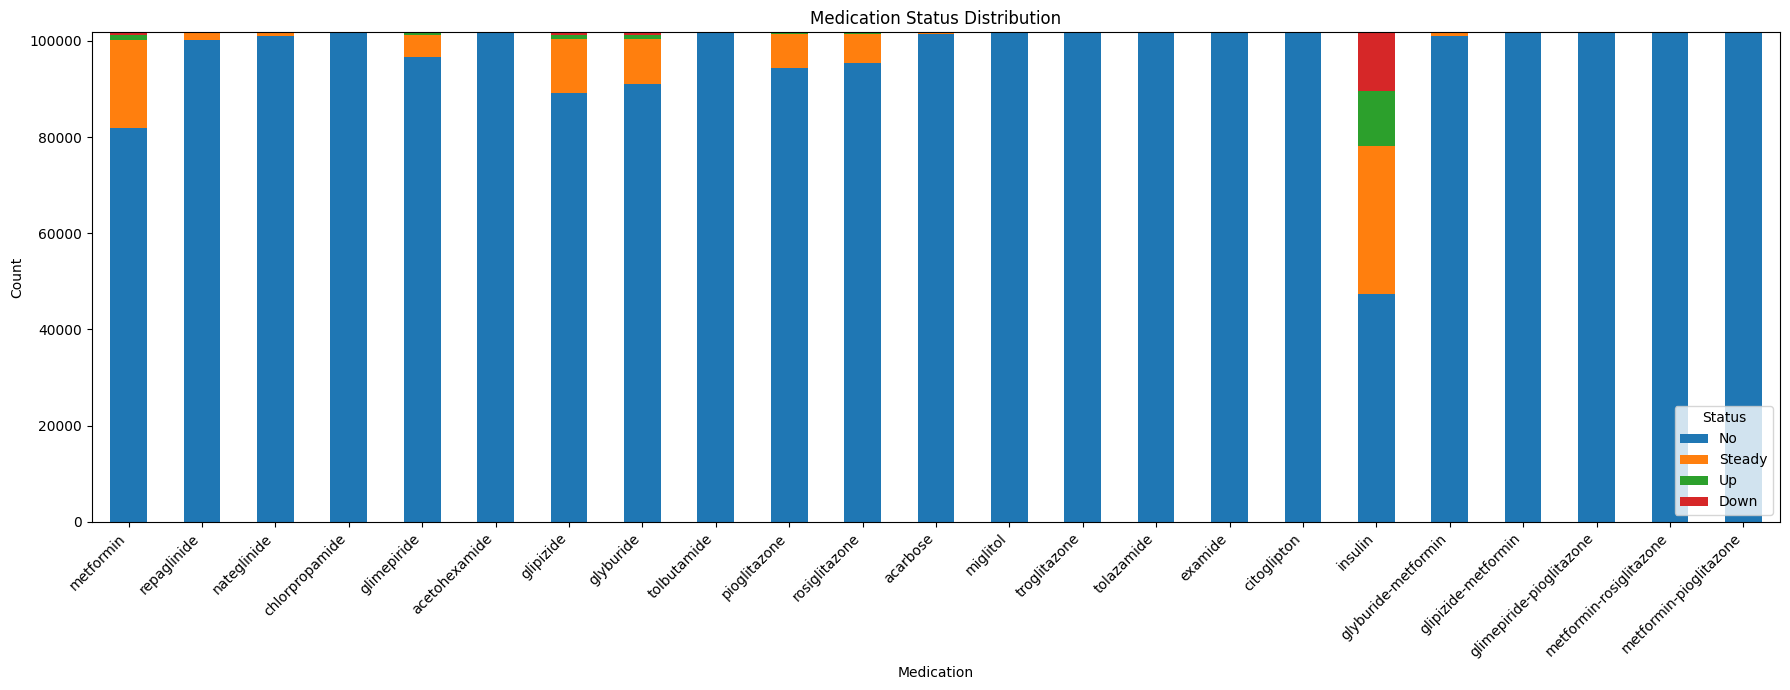

In [13]:
medication_cols = [
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone"
]

med_summary = pd.DataFrame()

for col in medication_cols:
    med_summary[col] = df[col].value_counts()

med_summary = med_summary.T.fillna(0)

med_summary.plot(kind="bar", stacked=True, figsize=(18, 7))

plt.title("Medication Status Distribution")
plt.xlabel("Medication")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Status",  loc="lower right")
plt.tight_layout()
plt.show()

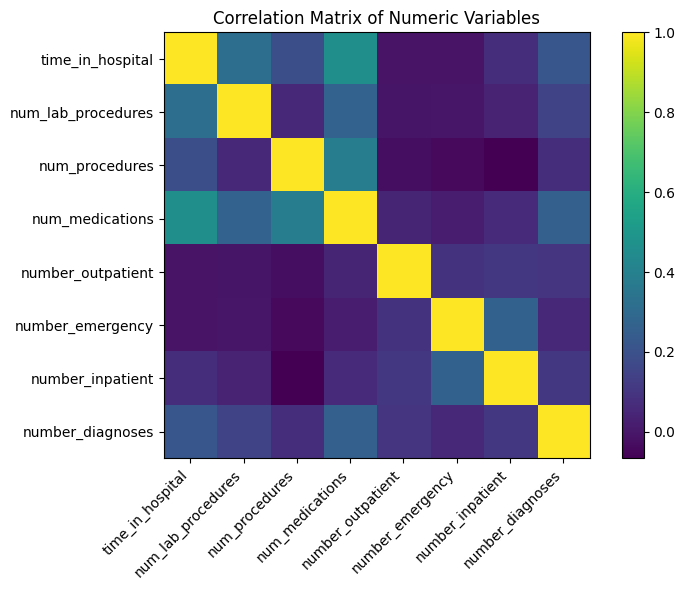

In [14]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))

plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha="right")
plt.yticks(range(len(numeric_cols)), numeric_cols)

plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()

학습을 위한 라벨값 처리

In [15]:
df["target_30day_readmission"] = np.where(
    df["readmitted"] == "<30",
    "30-day readmission",
    "No 30-day readmission"
)

df["target_30day_readmission"].value_counts()

,count
target_30day_readmission,
No 30-day readmission,90409
30-day readmission,11357


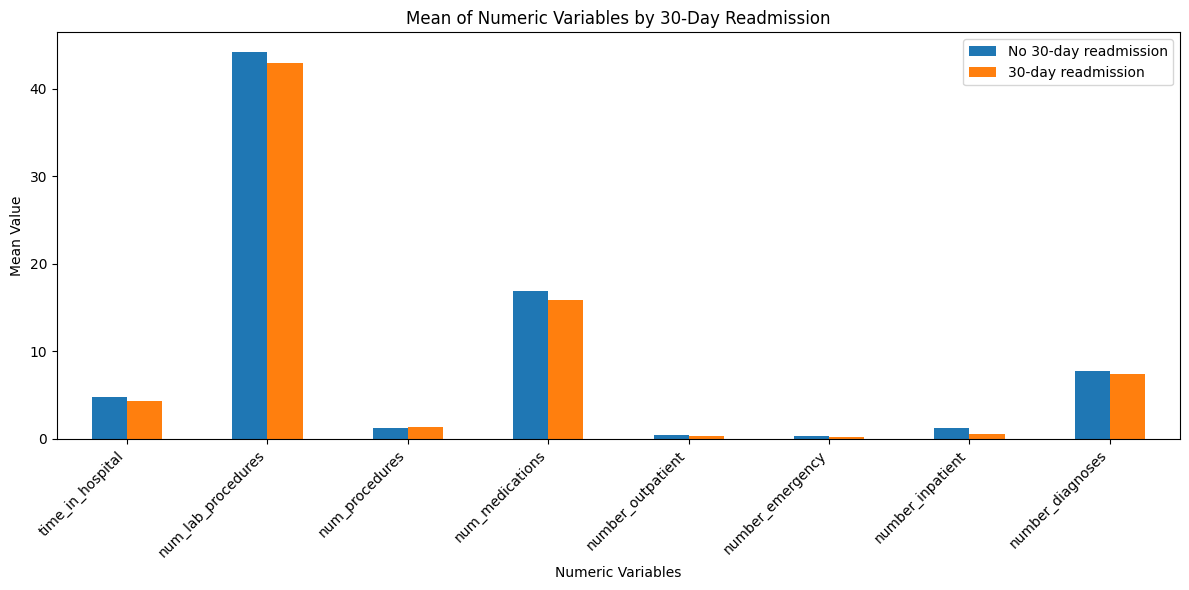

In [16]:
target_col = "target_30day_readmission"

group_mean = df.groupby(target_col)[numeric_cols].mean()

group_mean.T.plot(kind="bar", figsize=(12, 6))

plt.title("Mean of Numeric Variables by 30-Day Readmission")
plt.xlabel("Numeric Variables")
plt.ylabel("Mean Value")
plt.xticks(rotation=45, ha="right")
plt.legend(["No 30-day readmission", "30-day readmission"])
plt.tight_layout()
plt.show()

In [17]:

from scipy.stats import chi2_contingency, mannwhitneyu

def format_n_pct(n, denominator):
    return f"{int(n):,} ({n / denominator * 100:.1f})"

def format_median_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    med = series.median()
    return f"{med:.0f} [{q1:.0f}-{q3:.0f}]"

def format_pvalue(p):
    if p < 0.001:
        return "<0.001"
    else:
        return f"{p:.3f}"

# 논문 Table 1에 넣을 변수 선택

continuous_vars = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

categorical_vars = [
    "gender",
    "race",
    "age",
    "A1Cresult",
    "max_glu_serum",
    "insulin",
    "change",
    "diabetesMed"
]

# '?'는 표에서 Unknown으로 표시
df_table = df.copy()
df_table = df_table.replace("?", "Unknown")


group_col = "target_30day_readmission"

rows = []
overall_n = len(df_table)
no_df = df_table[df_table[group_col] == "No 30-day readmission"]
yes_df = df_table[df_table[group_col] == "30-day readmission"]

no_n = len(no_df)
yes_n = len(yes_df)

rows.append({
    "Variable": "N",
    "Overall": f"{overall_n:,}",
    "No 30-day readmission": f"{no_n:,}",
    "30-day readmission": f"{yes_n:,}",
    "p-value": ""
})

# 연속형 변수: median [IQR] -> Mann-Whitney U test
for col in continuous_vars:
    s_no = no_df[col]
    s_yes = yes_df[col]

    p = mannwhitneyu(s_no, s_yes, alternative="two-sided").pvalue

    rows.append({
        "Variable": f"{col}, median [IQR]",
        "Overall": format_median_iqr(df_table[col]),
        "No 30-day readmission": format_median_iqr(s_no),
        "30-day readmission": format_median_iqr(s_yes),
        "p-value": format_pvalue(p)
    })

# 범주형 변수: n (%) -> 카이제곱 독립성 검정, chi-square test of independence
for col in categorical_vars:
    contingency_table = pd.crosstab(df_table[col], df_table[group_col])
    p = chi2_contingency(contingency_table)[1]

    rows.append({
        "Variable": col,
        "Overall": "",
        "No 30-day readmission": "",
        "30-day readmission": "",
        "p-value": format_pvalue(p)
    })

    levels = df_table[col].value_counts().index

    for level in levels:
        overall_count = (df_table[col] == level).sum()
        no_count = ((df_table[col] == level) & (df_table[group_col] == "No 30-day readmission")).sum()
        yes_count = ((df_table[col] == level) & (df_table[group_col] == "30-day readmission")).sum()

        rows.append({
            "Variable": f"  {level}",
            "Overall": format_n_pct(overall_count, overall_n),
            "No 30-day readmission": format_n_pct(no_count, no_n),
            "30-day readmission": format_n_pct(yes_count, yes_n),
            "p-value": ""
        })

table1 = pd.DataFrame(rows)

In [18]:
table1

,Variable,Overall,No 30-day readmission,30-day readmission,p-value
0,N,"101,766","90,409","11,357",
1,"time_in_hospital, median [IQR]",4 [2-6],4 [2-6],4 [2-6],<0.001
2,"num_lab_procedures, median [IQR]",44 [31-57],44 [31-57],45 [33-58],<0.001
3,"num_procedures, median [IQR]",1 [0-2],1 [0-2],1 [0-2],0.051
4,"num_medications, median [IQR]",15 [10-20],15 [10-20],16 [11-21],<0.001
5,"number_outpatient, median [IQR]",0 [0-0],0 [0-0],0 [0-0],<0.001
6,"number_emergency, median [IQR]",0 [0-0],0 [0-0],0 [0-0],<0.001
7,"number_inpatient, median [IQR]",0 [0-1],0 [0-1],0 [0-2],<0.001
8,"number_diagnoses, median [IQR]",8 [6-9],8 [6-9],9 [6-9],<0.001
9,gender,,,,0.539


# 결측치 이해하기

## 1. 결측치란?

결측치, 또는 missing value란 데이터에서 **값이 비어 있거나 기록되지 않은 상태**를 의미한다.

의료 데이터에서는 환자의 모든 정보가 항상 완벽하게 기록되지 않는다.  
예를 들어 어떤 환자는 체중 정보가 없을 수 있고, 어떤 환자는 특정 검사 결과가 기록되지 않았을 수 있다.

즉, 결측치는 다음과 같은 상황에서 발생할 수 있다.

- 실제로 검사가 시행되지 않은 경우
- 검사는 시행되었지만 EMR에 값이 입력되지 않은 경우
- 환자가 응답하지 않은 경우
- 데이터 추출 과정에서 값이 누락된 경우
- 개인정보 보호 또는 비식별화 과정에서 값이 제거된 경우

---

## 2. 결측치의 예시

예를 들어 다음과 같은 CSV 데이터가 있다고 하자.

| patient_id | age | gender | weight | HbA1c |
|---|---:|---|---:|---:|
| 1 | 65 | Female | 60 | 7.2 |
| 2 | 72 | Male |  | 8.1 |
| 3 | 58 | Female | 55 |  |
| 4 | 81 | Male | 70 | 6.9 |

위 표에서 2번 환자는 `weight` 값이 없고, 3번 환자는 `HbA1c` 값이 없다.  
이처럼 특정 변수의 값이 비어 있는 경우를 결측치라고 한다.

Python에서는 결측치가 보통 `NaN`으로 표시된다.

---

## 3. 의료 데이터에서 결측치가 중요한 이유

의료 AI 분석에서 결측치는 매우 중요하다.  
결측치를 제대로 처리하지 않으면 분석 결과나 AI 모델 성능에 영향을 줄 수 있다.

예를 들어 다음과 같은 문제가 발생할 수 있다.

1. 결측치가 포함된 상태에서는 일부 통계 계산이 제대로 되지 않을 수 있다.
2. 머신러닝 모델은 결측값을 그대로 입력받지 못하는 경우가 많다.
3. 결측치가 특정 환자군에 많이 발생하면 데이터 편향이 생길 수 있다.
4. 결측 자체가 임상적으로 의미 있는 정보일 수 있다.

예를 들어 HbA1c 값이 없는 것은 단순 누락이 아니라, 해당 입원 중 HbA1c 검사가 시행되지 않았다는 의미일 수 있다.

---

## 4. 결측치와 미기록 값의 차이

의료 데이터에서는 단순히 값이 비어 있는 것뿐만 아니라, 특정 기호로 미기록 값을 표시하는 경우도 많다.

예를 들어 이번 강의에서 사용할 Diabetes 데이터셋에서는 일부 결측 또는 미기록 값이 `?`로 표시되어 있다.

| 표현 | 의미 |
|---|---|
| `NaN` | Python 또는 pandas에서 인식하는 결측값 |
| 빈 칸 | 값이 입력되지 않음 |
| `?` | 원본 데이터에서 미기록 또는 알 수 없음으로 표시된 값 |
| `None` | 값이 없음을 의미할 수도 있지만, 데이터셋에 따라 하나의 범주일 수도 있음 |

따라서 데이터를 분석하기 전에는 결측값이 어떤 방식으로 표시되어 있는지 반드시 확인해야 한다.

---

## 5. Diabetes 데이터셋에서의 결측치

이번 강의에서 사용하는 **Diabetes 130-US Hospitals** 데이터셋에서는 결측 또는 미기록 값이 주로 `?`로 표시된다.

예를 들어 다음 변수에서 `?`가 많이 나타날 수 있다.

| 변수명 | 의미 |
|---|---|
| `weight` | 체중 |
| `payer_code` | 보험 또는 지불자 코드 |
| `medical_specialty` | 입원 담당 의사의 진료과 |
| `race` | 인종 정보 |
| `diag_1`, `diag_2`, `diag_3` | 진단 코드 |

특히 `weight`는 결측 비율이 매우 높기 때문에, 실제 분석에서는 제외하거나 별도의 범주로 처리하는 것을 고려할 수 있다.

---

## 6. 결측치 확인 방법

pandas에서는 다음과 같이 결측치를 확인할 수 있다.

```python
df.isnull().sum()

In [19]:
df.isnull().sum().sort_values(ascending=False)

,0
max_glu_serum,96420
A1Cresult,84748
encounter_id,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


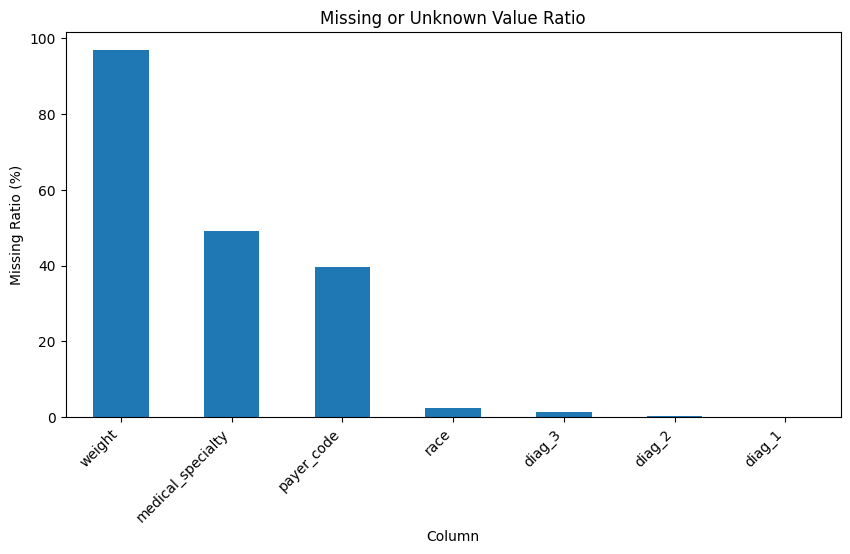

In [20]:
import matplotlib.pyplot as plt

missing_ratio = (df == "?").sum() / len(df) * 100
missing_ratio = missing_ratio[missing_ratio > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
missing_ratio.plot(kind="bar")
plt.title("Missing or Unknown Value Ratio")
plt.xlabel("Column")
plt.ylabel("Missing Ratio (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

In [21]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
}).round(2)

print(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=False))

               Missing Count  Missing Percentage (%)
max_glu_serum          96420                   94.75
A1Cresult              84748                   83.28


# 전처리 이후: 인공지능 모델은 어떻게 학습되는가?

지금까지 우리는 CSV 파일을 불러오고, 데이터 구조를 확인하고, 결측치와 변수 유형을 살펴보았다.  
이 과정은 단순한 데이터 정리가 아니라, **AI 모델이 학습할 수 있는 형태로 데이터를 준비하는 단계**이다.

의료 AI에서 인공지능 모델을 만든다는 것은 보통 다음과 같은 과정을 의미한다.

---

## 1. AI 모델 학습의 기본 흐름

의료 CSV 데이터를 이용한 AI 모델 개발은 일반적으로 다음 순서로 진행된다.

1. 데이터 수집
2. CSV 파일 불러오기
3. 데이터 구조 확인
4. 결측치 처리
5. 범주형 변수와 수치형 변수 구분
6. Feature와 Target 정의
7. 학습용 데이터와 평가용 데이터 분리
8. AI 모델 학습
9. 모델 성능 평가
10. 결과 해석

즉, 오늘 배운 CSV 확인과 전처리는 AI 모델 학습의 출발점이다.

---

## 2. Feature와 Target

AI 모델은 입력값을 받아서 정답을 예측하도록 학습된다.

| 구분 | 의미 | 이번 데이터셋 예시 |
|---|---|---|
| Feature | 모델에 입력되는 변수 | 나이, 성별, 입원 기간, 검사 수, 약물 정보, 진단 코드 |
| Target | 모델이 예측해야 하는 정답 | 30일 이내 재입원 여부 |

이번 Diabetes 데이터셋에서는 `readmitted` 컬럼을 이용해 target을 만들 수 있다.

| 기존 값 | 의미 | 변환 후 target |
|---|---|---|
| `<30` | 30일 이내 재입원 | 1 |
| `>30` | 30일 이후 재입원 | 0 |
| `NO` | 재입원 없음 | 0 |

따라서 AI 모델의 목표는 다음과 같이 정의할 수 있다.

**입원 중 기록된 EMR 정보를 이용하여 퇴원 후 30일 이내 재입원 여부를 예측한다.**

---

## 3. 왜 전처리가 필요한가?

AI 모델은 사람이 보는 방식으로 데이터를 이해하지 못한다.  
따라서 CSV에 들어 있는 값을 모델이 이해할 수 있는 형태로 바꿔야 한다.

예를 들어 다음과 같은 처리가 필요하다.

| 데이터 형태 | 전처리 필요성 |
|---|---|
| 결측값 | 모델이 처리할 수 있도록 삭제, 대체, Unknown 처리 필요 |
| 성별, 인종, 약물명 | 문자형 범주이므로 숫자 형태로 인코딩 필요 |
| 진단 코드 | 숫자처럼 보여도 실제로는 범주형 코드이므로 주의 필요 |
| 검사 수, 입원 기간 | 수치형 변수로 사용할 수 있음 |
| 환자 ID | 예측에 직접 사용하지 않는 것이 일반적 |

즉, 좋은 AI 모델을 만들기 위해서는 먼저 좋은 입력 데이터를 만들어야 한다.

---

## 4. 간단한 AI 모델 학습 예시

아래 코드는 전처리된 데이터를 이용해 간단한 머신러닝 모델을 학습하는 예시이다.  
강의에서는 전체 원리를 이해하는 정도로만 보면 된다.

```python
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report